# AURA — Autoencoder-based Unsupervised Fraud Detection

**Bank Account Fraud (BAF) dataset, NeurIPS 2022**

This notebook trains an **unsupervised autoencoder** to flag fraudulent bank-account
opening applications. The model learns to reconstruct *normal* transactions only; at
inference, transactions with high reconstruction error are flagged as anomalous
(potentially fraudulent). We compare against an **Isolation Forest** baseline and
evaluate with metrics appropriate for a highly imbalanced problem (fraud ≈ 1.1%).

**Method highlights (and what was fixed from the original project):**
- Leakage-free pipeline: split **first**, then fit all preprocessing (imputation,
  clipping, scaling, one-hot levels) on the *training-normal* subset only.
- Correct handling of the BAF `-1` missing-value sentinel (adds missing-indicator
  features) — the original code did a naive `fillna(0)`.
- Correct categorical cardinality: `employment_status` and `housing_status` each
  have **7** categories (the original code assumed 5, silently corrupting rows).
- Min-Max scaling + 1st/99th-percentile outlier clipping on continuous features.
- Threshold chosen on the **validation** set (not the test set).
- Honest, imbalance-aware evaluation: **PR-AUC / Average Precision** as the headline,
  alongside ROC-AUC, and a baseline comparison.

Runs on CPU or GPU; set the runtime to a **GPU** in Colab (`Runtime → Change runtime
type → T4 GPU`) for faster training.

## 1. Setup

In [1]:
# Colab already has torch, sklearn, pandas, matplotlib. If running elsewhere:
# !pip install torch pandas numpy scikit-learn matplotlib
import os, json, time, random, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score)
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch 2.13.0+cu130 | Device: cpu


## 2. Get the data

The **Base.csv** variant of the [BAF dataset](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022)
(~1M rows). Pick whichever source is convenient — the cell tries several locations.

**Option A (Kaggle API):** upload your `kaggle.json` token, then the cell downloads
automatically. **Option B:** upload `Base.csv` via the Colab file panel. **Option C:**
mount Google Drive and point `DATA_PATH` at your copy.

In [2]:
DATA_PATH = "Base.csv"   # <-- change if needed

def try_kaggle():
    if not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        return False
    os.system("pip -q install kaggle")
    os.system("kaggle datasets download -d sgpjesus/bank-account-fraud-dataset-neurips-2022 "
              "-f Base.csv -p . && unzip -o Base.csv.zip 2>/dev/null")
    return os.path.exists("Base.csv")

candidates = [DATA_PATH, "/content/Base.csv",
              "/content/drive/MyDrive/Base.csv", "data/raw/Base.csv"]
path = next((p for p in candidates if os.path.exists(p)), None)
if path is None and try_kaggle():
    path = "Base.csv"
assert path, ("Could not find Base.csv. Upload it, or place kaggle.json in ~/.kaggle/. "
              "See the markdown above.")
DATA_PATH = path
print("Using:", DATA_PATH)

Using: Base.csv


## 3. Load & explore

In [3]:
df = pd.read_csv(DATA_PATH)
TARGET = "fraud_bool"
print("Shape:", df.shape)
print("Fraud rate: %.4f%%  (n_fraud = %d)" % (100*df[TARGET].mean(), int(df[TARGET].sum())))
df.head(3)

Shape: (1000000, 32)
Fraud rate: 1.1029%  (n_fraud = 11029)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0


In [4]:
# Column roles
CAT = ["payment_type", "employment_status", "housing_status", "source", "device_os"]
for c in CAT:
    print(f"{c:20s} {df[c].nunique()} categories: {sorted(df[c].unique())}")
print("\nConstant columns:", [c for c in df.columns if df[c].nunique() == 1])
print("\n-1 missing-sentinel prevalence:")
for c in df.select_dtypes('number').columns:
    frac = (df[c] == -1).mean()
    if frac > 0: print(f"  {c:32s} {100*frac:5.2f}% are -1")

payment_type         5 categories: ['AA', 'AB', 'AC', 'AD', 'AE']
employment_status    7 categories: ['CA', 'CB', 'CC', 'CD', 'CE', 'CF', 'CG']


housing_status       7 categories: ['BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG']
source               2 categories: ['INTERNET', 'TELEAPP']


device_os            5 categories: ['linux', 'macintosh', 'other', 'windows', 'x11']



Constant columns: ['device_fraud_count']

-1 missing-sentinel prevalence:
  prev_address_months_count        71.29% are -1
  current_address_months_count      0.43% are -1
  credit_risk_score                 0.05% are -1
  bank_months_count                25.36% are -1
  session_length_in_minutes         0.20% are -1
  device_distinct_emails_8w         0.04% are -1


Two data-quality facts that break naive pipelines: `employment_status` and
`housing_status` have **7** categories (not 5), and several columns encode *missing*
as `-1` (e.g. `prev_address_months_count` is 71% missing). `device_fraud_count` is
constant and is dropped.

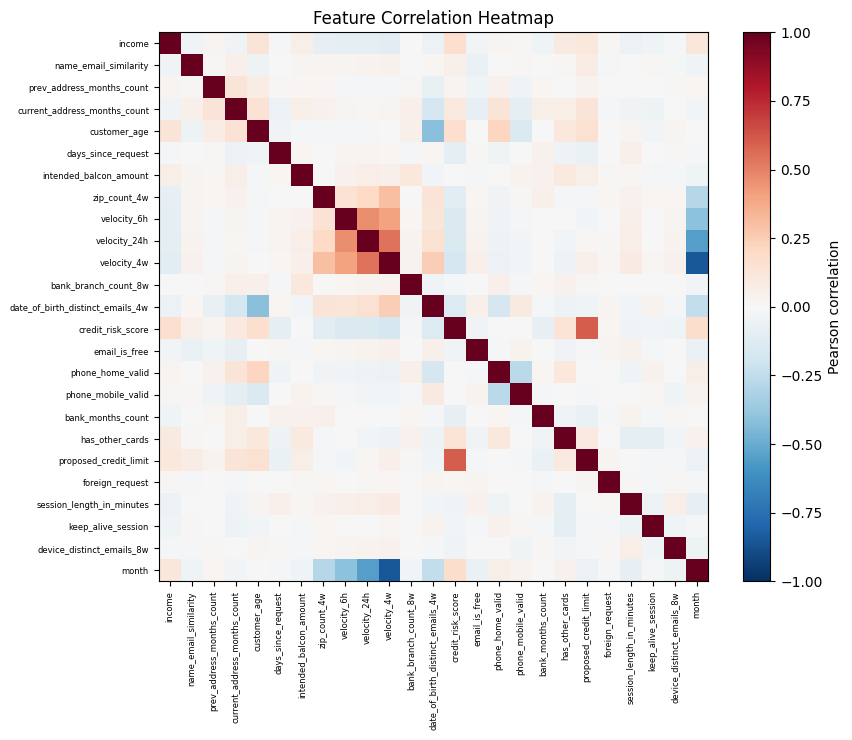

Strongest correlation: velocity_4w ~ month = -0.848


In [5]:
import numpy as np
num = df.drop(columns=["device_fraud_count"]).select_dtypes('number').drop(columns=[TARGET])
SENTINEL = ["prev_address_months_count","current_address_months_count","credit_risk_score",
            "bank_months_count","session_length_in_minutes","device_distinct_emails_8w"]
nn_ = num.copy()
for c in SENTINEL: nn_[c] = nn_[c].replace(-1, np.nan)
corr = nn_.corr()
plt.figure(figsize=(9,7.5))
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, label="Pearson correlation")
plt.xticks(range(len(corr)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr)), corr.columns, fontsize=6)
plt.title("Feature Correlation Heatmap"); plt.tight_layout(); plt.show()
c = corr.abs().values.copy(); np.fill_diagonal(c, 0)
i,j = np.unravel_index(c.argmax(), c.shape)
print("Strongest correlation: %s ~ %s = %.3f" % (corr.columns[i], corr.columns[j], corr.values[i,j]))

## 4. Leakage-free preprocessing
Split **first** (50/25/25 stratified), then fit every transform on **training-normal rows only**.

In [6]:
DROP_CONST = ["device_fraud_count"]
df = df.drop(columns=DROP_CONST)
num_cols = [c for c in df.columns if c not in CAT + [TARGET]]
BINARY = [c for c in num_cols if set(df[c].dropna().unique()) <= {0,1}]
CONT   = [c for c in num_cols if c not in BINARY]

train_df, temp_df = train_test_split(df, test_size=0.5, random_state=SEED, stratify=df[TARGET])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df[TARGET])
train_normal = train_df[train_df[TARGET] == 0].copy()
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  train-normal={len(train_normal)}")

CAT_LEVELS = {c: sorted(train_df[c].unique().tolist()) for c in CAT}
impute_median, clip_lo, clip_hi, scale_min, scale_max = {}, {}, {}, {}, {}
_f = train_normal.copy()
for c in SENTINEL: _f[c] = _f[c].replace(-1, np.nan)
for c in CONT:
    med = _f[c].median(); impute_median[c] = float(med)
    col = _f[c].fillna(med)
    lo, hi = np.percentile(col,1), np.percentile(col,99)
    clip_lo[c], clip_hi[c] = float(lo), float(hi)
    col = col.clip(lo,hi); scale_min[c], scale_max[c] = float(col.min()), float(col.max())

def transform(frame):
    f = frame.copy()
    for c in SENTINEL:
        f[c+"_missing"] = (f[c] == -1).astype(float); f[c] = f[c].replace(-1, np.nan)
    for c in CONT:
        col = f[c].fillna(impute_median[c]).clip(clip_lo[c], clip_hi[c])
        rng = scale_max[c]-scale_min[c]
        f[c] = (col-scale_min[c])/rng if rng>0 else 0.0
    parts = [f[CONT+BINARY+[s+"_missing" for s in SENTINEL]]]
    for c in CAT:
        d = pd.get_dummies(f[c], prefix=c)
        for lv in CAT_LEVELS[c]:
            if f"{c}_{lv}" not in d.columns: d[f"{c}_{lv}"] = 0
        parts.append(d[[f"{c}_{lv}" for lv in CAT_LEVELS[c]]].astype(float))
    return pd.concat(parts, axis=1)

X_train = transform(train_normal).values.astype(np.float32)
Xv = transform(val_df);  y_val  = val_df[TARGET].values
Xt = transform(test_df); y_test = test_df[TARGET].values
FEATURES = Xv.columns.tolist()
X_val, X_test = Xv.values.astype(np.float32), Xt.values.astype(np.float32)
INPUT_DIM = X_train.shape[1]
print("Feature dim after encoding:", INPUT_DIM)

train=500000  val=250000  test=250000  train-normal=494485


Feature dim after encoding: 57


## 5. Autoencoder
Symmetric encoder/decoder with BatchNorm + Dropout; sigmoid output matches the [0,1] scaled inputs. Bottleneck = 16.

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, d, p=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64,32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(p),
            nn.Linear(32,16))
        self.decoder = nn.Sequential(
            nn.Linear(16,32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(p),
            nn.Linear(32,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(p),
            nn.Linear(64,d), nn.Sigmoid())
        for m in self.modules():
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight)
    def forward(self, x): return self.decoder(self.encoder(x))

model = Autoencoder(INPUT_DIM).to(DEVICE)
print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters()))

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=57, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Line

## 6. Train (early stopping on held-out normal loss)

In [8]:
crit = nn.MSELoss()
opt  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
tr, es = train_test_split(X_train, test_size=0.1, random_state=SEED)
tr_loader = DataLoader(TensorDataset(torch.tensor(tr)), batch_size=256, shuffle=True)
es_t = torch.tensor(es).to(DEVICE)

def recon_mse(m, X, bs=8192):
    m.eval(); out=[]
    with torch.no_grad():
        for i in range(0,len(X),bs):
            xb=torch.tensor(X[i:i+bs]).to(DEVICE); out.append(((xb-m(xb))**2).mean(1).cpu().numpy())
    return np.concatenate(out)

EPOCHS, best, patience, bad, hist = 60, np.inf, 8, 0, []
t0=time.time()
for ep in range(EPOCHS):
    model.train(); tot=0
    for (xb,) in tr_loader:
        xb=xb.to(DEVICE); opt.zero_grad(); loss=crit(model(xb),xb); loss.backward(); opt.step()
        tot += loss.item()*len(xb)
    model.eval()
    with torch.no_grad(): vloss=crit(model(es_t), es_t).item()
    hist.append((ep+1, tot/len(tr), vloss))
    if vloss < best-1e-6: best=vloss; bad=0; torch.save(model.state_dict(),"autoencoder_final.pt")
    else: bad+=1
    if (ep+1)%5==0 or ep==0: print(f"epoch {ep+1:02d}  train {tot/len(tr):.5f}  es {vloss:.5f}  (best {best:.5f})")
    if bad>=patience: print("early stop @", ep+1); break
print("train time: %.1fs on %s" % (time.time()-t0, DEVICE))
model.load_state_dict(torch.load("autoencoder_final.pt"))
hist=np.array(hist)

epoch 01  train 0.04633  es 0.02355  (best 0.02355)


epoch 05  train 0.02362  es 0.01515  (best 0.01515)


epoch 10  train 0.01974  es 0.01256  (best 0.01256)


epoch 15  train 0.01860  es 0.01112  (best 0.01112)


epoch 20  train 0.01833  es 0.01119  (best 0.01103)


epoch 25  train 0.01832  es 0.01112  (best 0.01103)


early stop @ 27
train time: 169.9s on cpu


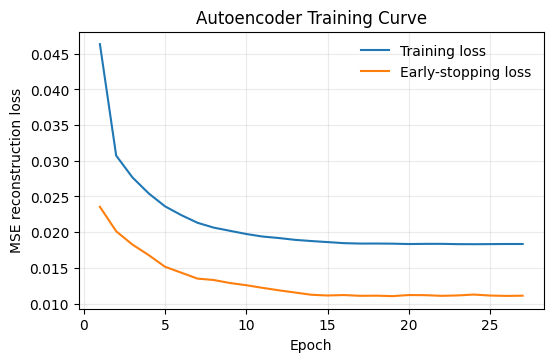

In [9]:
plt.figure(figsize=(6,3.6))
plt.plot(hist[:,0],hist[:,1],label="Training loss")
plt.plot(hist[:,0],hist[:,2],label="Early-stopping loss")
plt.xlabel("Epoch"); plt.ylabel("MSE reconstruction loss")
plt.title("Autoencoder Training Curve"); plt.legend(frameon=False); plt.grid(alpha=.25); plt.show()

## 7. Threshold on validation, evaluate on test

In [10]:
val_mse, test_mse = recon_mse(model, X_val), recon_mse(model, X_test)
prec, rec, thr = precision_recall_curve(y_val, val_mse)
f1s = 2*prec*rec/(prec+rec+1e-12)
best_thr = float(thr[np.argmax(f1s[:-1])])

def evaluate(y, mse, thr):
    yp=(mse>thr).astype(int)
    return dict(roc_auc=roc_auc_score(y,mse), pr_auc=average_precision_score(y,mse),
        accuracy=accuracy_score(y,yp), precision=precision_score(y,yp,zero_division=0),
        recall=recall_score(y,yp,zero_division=0), f1=f1_score(y,yp,zero_division=0),
        cm=confusion_matrix(y,yp),
        report=classification_report(y,yp,target_names=["Normal","Fraud"],zero_division=0))
ae = evaluate(y_test, test_mse, best_thr)
print(f"Threshold (from val): {best_thr:.4f}\n")
for k in ["roc_auc","pr_auc","accuracy","precision","recall","f1"]:
    print(f"  {k:10s}: {ae[k]:.4f}")
print("\n"+ae["report"])

Threshold (from val): 0.0248

  roc_auc   : 0.5917
  pr_auc    : 0.0163
  accuracy  : 0.9150
  precision : 0.0218
  recall    : 0.1531
  f1        : 0.0382

              precision    recall  f1-score   support

      Normal       0.99      0.92      0.96    247243
       Fraud       0.02      0.15      0.04      2757

    accuracy                           0.91    250000
   macro avg       0.51      0.54      0.50    250000
weighted avg       0.98      0.91      0.95    250000



## 8. Isolation Forest baseline

In [11]:
iso = IsolationForest(n_estimators=100, contamination='auto', random_state=SEED, n_jobs=-1)
iso.fit(X_train)
iso_test = -iso.score_samples(X_test)
p2,r2,t2 = precision_recall_curve(y_val, -iso.score_samples(X_val))
iso_thr = float(t2[np.argmax((2*p2*r2/(p2+r2+1e-12))[:-1])])
iso_res = evaluate(y_test, iso_test, iso_thr)
print("Isolation Forest — ROC-AUC %.4f  PR-AUC %.4f  F1 %.4f" %
      (iso_res["roc_auc"], iso_res["pr_auc"], iso_res["f1"]))

Isolation Forest — ROC-AUC 0.5530  PR-AUC 0.0141  F1 0.0291


## 9. Results & figures

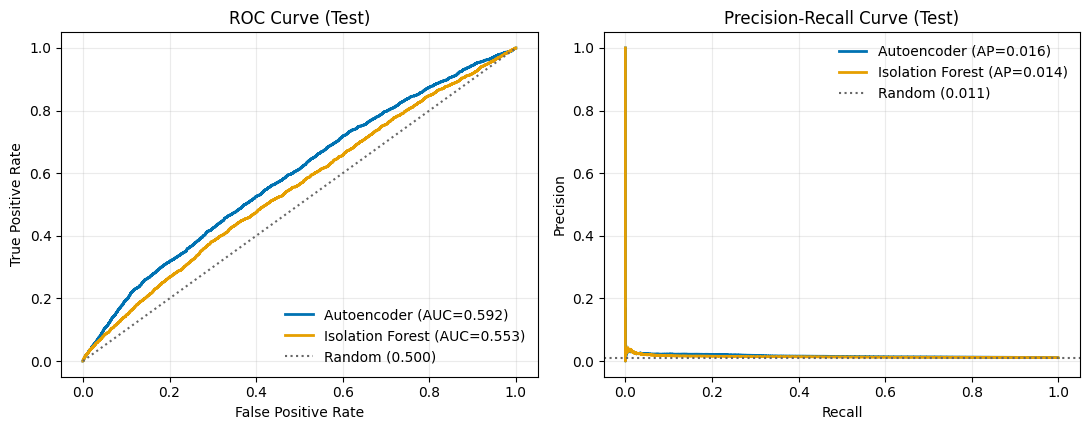

In [12]:
BLUE,VERM,ORANGE,GREY="#0072B2","#D55E00","#E69F00","#666666"
base=y_test.mean()
fig,ax=plt.subplots(1,2,figsize=(11,4.4))
f,t,_=roc_curve(y_test,test_mse); fi,ti,_=roc_curve(y_test,iso_test)
ax[0].plot(f,t,color=BLUE,lw=2,label=f"Autoencoder (AUC={ae['roc_auc']:.3f})")
ax[0].plot(fi,ti,color=ORANGE,lw=2,label=f"Isolation Forest (AUC={iso_res['roc_auc']:.3f})")
ax[0].plot([0,1],[0,1],color=GREY,ls=":",label="Random (0.500)")
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve (Test)"); ax[0].legend(frameon=False,loc="lower right"); ax[0].grid(alpha=.25)
p,r,_=precision_recall_curve(y_test,test_mse); pi,ri,_=precision_recall_curve(y_test,iso_test)
ax[1].plot(r,p,color=BLUE,lw=2,label=f"Autoencoder (AP={ae['pr_auc']:.3f})")
ax[1].plot(ri,pi,color=ORANGE,lw=2,label=f"Isolation Forest (AP={iso_res['pr_auc']:.3f})")
ax[1].axhline(base,color=GREY,ls=":",label=f"Random ({base:.3f})")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall Curve (Test)")
ax[1].legend(frameon=False); ax[1].grid(alpha=.25); plt.tight_layout(); plt.show()

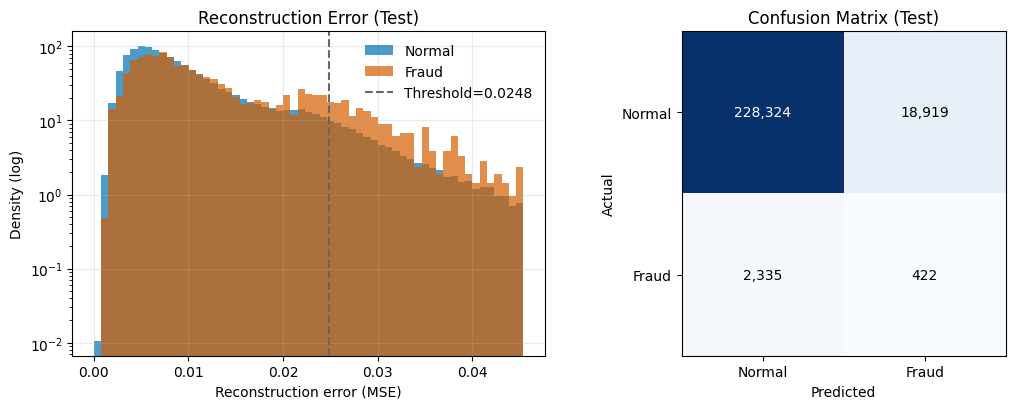

In [13]:
fig,ax=plt.subplots(1,2,figsize=(11,4.2))
bins=np.linspace(0,np.percentile(test_mse,99.5),60)
ax[0].hist(test_mse[y_test==0],bins=bins,color=BLUE,alpha=.7,density=True,label="Normal")
ax[0].hist(test_mse[y_test==1],bins=bins,color=VERM,alpha=.7,density=True,label="Fraud")
ax[0].axvline(best_thr,color=GREY,ls="--",label=f"Threshold={best_thr:.4f}")
ax[0].set_yscale("log"); ax[0].set_xlabel("Reconstruction error (MSE)"); ax[0].set_ylabel("Density (log)")
ax[0].set_title("Reconstruction Error (Test)"); ax[0].legend(frameon=False); ax[0].grid(alpha=.25)
cm=ae["cm"]
ax[1].imshow(cm,cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[1].text(j,i,f"{cm[i,j]:,}",ha="center",va="center",
                   color="white" if cm[i,j]>cm.max()/2 else "black")
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["Normal","Fraud"])
ax[1].set_yticks([0,1]); ax[1].set_yticklabels(["Normal","Fraud"])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual"); ax[1].set_title("Confusion Matrix (Test)")
plt.tight_layout(); plt.show()

In [14]:
summary = pd.DataFrame({
    "Model":["Autoencoder","Isolation Forest","Random baseline"],
    "ROC-AUC":[ae["roc_auc"], iso_res["roc_auc"], 0.5],
    "PR-AUC (AP)":[ae["pr_auc"], iso_res["pr_auc"], base],
    "Precision":[ae["precision"], iso_res["precision"], base],
    "Recall":[ae["recall"], iso_res["recall"], np.nan],
    "F1":[ae["f1"], iso_res["f1"], np.nan],
}).round(4)
summary

,Model,ROC-AUC,PR-AUC (AP),Precision,Recall,F1
0,Autoencoder,0.5917,0.0163,0.0218,0.1531,0.0382
1,Isolation Forest,0.5530,0.0141,0.0163,0.1346,0.0291
2,Random baseline,0.5000,0.0110,0.0110,NaN,NaN


## 10. Discussion

On the BAF dataset, a purely **unsupervised** autoencoder reaches **ROC-AUC ≈ 0.59**
and **PR-AUC ≈ 0.016** on held-out test data — a real but modest lift over both the
Isolation Forest baseline (ROC-AUC ≈ 0.55) and random (PR-AUC = fraud prevalence ≈
0.011). Because it never sees a fraud label, the autoencoder cannot separate the
classes as well as a supervised model would (published supervised baselines on BAF
reach ROC-AUC ≈ 0.85+). Its value is as a **label-free first-line filter**: it needs
no fraud labels, adapts as "normal" drifts, and narrows the review population for a
downstream supervised model or human analyst.

**Why accuracy is the wrong metric here:** flagging *nothing* already yields ~98.9%
accuracy. We therefore report PR-AUC and the precision/recall trade-off, which reflect
the real cost structure of fraud review.

**Next steps:** combine reconstruction error with a supervised head (semi-supervised),
add temporal/sequence modelling (LSTM autoencoder), and per-feature error attribution
for explainability.